In [16]:
#Imports 


import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [20]:
df_chickwts = pd.read_csv('chickwts.csv')
df_chickwts.head()

,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


In [21]:
df_chickwts.shape


(71, 3)

In [23]:
df_chickwts.columns

Index(['rownames', 'weight', 'feed'], dtype='str')

In [24]:
df_chickwts.info

<bound method DataFrame.info of     rownames  weight       feed
0          1     179  horsebean
1          2     160  horsebean
2          3     136  horsebean
3          4     227  horsebean
4          5     217  horsebean
..       ...     ...        ...
66        67     359     casein
67        68     216     casein
68        69     222     casein
69        70     283     casein
70        71     332     casein

[71 rows x 3 columns]>

In [ ]:
#Data Quality 

In [22]:
(df_chickwts.isnull().sum())

rownames    0
weight      0
feed        0
dtype: int64

In [27]:
df_chickwts.duplicated().sum()

0

In [26]:
df_chickwts['feed'].value_counts

<bound method IndexOpsMixin.value_counts of 0     horsebean
1     horsebean
2     horsebean
3     horsebean
4     horsebean
        ...    
66       casein
67       casein
68       casein
69       casein
70       casein
Name: feed, Length: 71, dtype: str>

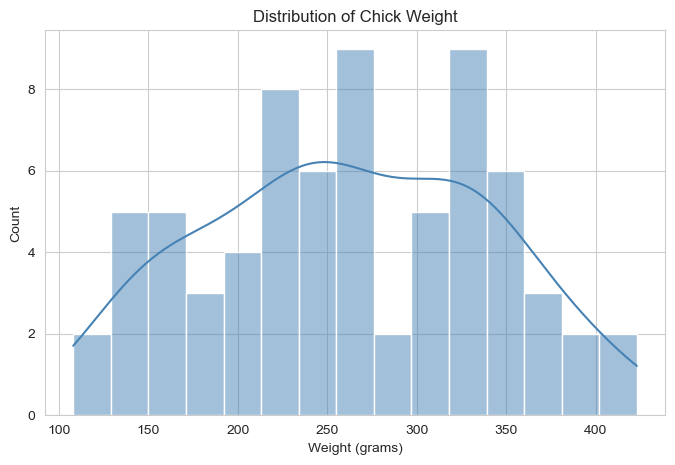

In [28]:
# Distribution of chick weight by plotting a histogram
plt.figure(figsize=(8, 5))
sns.histplot(df_chickwts['weight'], kde=True, bins=15, color='steelblue')
plt.title('Distribution of Chick Weight')
plt.xlabel('Weight (grams)')
plt.ylabel('Count')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_8652\2563683554.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='feed', y='weight', data=df_chickwts, palette='Set2')


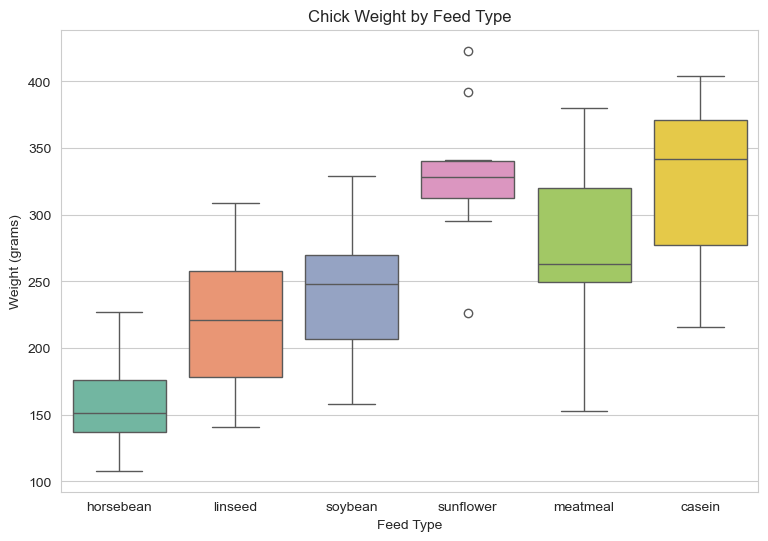

In [29]:
#Weight by type of Feed 
plt.figure(figsize=(9, 6))
sns.boxplot(x='feed', y='weight', data=df_chickwts, palette='Set2')
plt.title('Chick Weight by Feed Type')
plt.xlabel('Feed Type')
plt.ylabel('Weight (grams)')
plt.show()

In [ ]:
The boxplot shows clear differences between feed types. 
For instance, Sunflower and Casein produce the heaviest chicks on average  while horsebean consistently produces the lightest chicks with comparatively little spread.
Linseed and soybean fall in between. This confirms that feed type has a real, visible relationship with weight, which is exactly the signal we need for a similarity-based recommender.

In [30]:
#Standardizing the weight Feature 

scaler = StandardScaler()
df_chickwts['weight_scaled'] = scaler.fit_transform(df_chickwts[['weight']])

df_chickwts.head()

,rownames,weight,feed,weight_scaled
0,1,179,horsebean,-1.061762
1,2,160,horsebean,-1.306854
2,3,136,horsebean,-1.616444
3,4,227,horsebean,-0.442583
4,5,217,horsebean,-0.571578


In [31]:
# #Something to note
# A single chick's weight doesn't tell us anything about a feed type on its own — we need to summarize across all chicks that received a given feed. I'll compute the mean, standard deviation, minimum, and maximum of the standardized weight for each feed group, so each feed type becomes a comparable vector rather than a set of individual, unrelated numbers.

feed_profile = df_chickwts.groupby('feed')['weight_scaled'].agg(['mean', 'std', 'min', 'max']).reset_index()
feed_profile

,feed,mean,std,min,max
0,casein,0.803301,0.831169,-0.584478,1.840642
1,horsebean,-1.304274,0.498257,-1.977632,-0.442583
2,linseed,-0.549004,0.673818,-1.551946,0.615183
3,meatmeal,0.201223,0.837190,-1.397151,1.531052
4,soybean,-0.191962,0.698242,-1.332653,0.873174
5,sunflower,0.872099,0.629969,-0.455482,2.085734


In [32]:
#Model computation:
# The next step is to apply PCA to the feed profiles.
# Each feed type is now described by 4 numbers. I'll apply PCA to reduce this down to a single composite score per feed, capturing as much of the variation between feed types as possible in one number.
profile_matrix = feed_profile[['mean', 'std', 'min', 'max']].values

pca = PCA(n_components=1)
feed_profile['PC1'] = pca.fit_transform(profile_matrix)

print(f"Explained variance ratio: {pca.explained_variance_ratio_[0]:.4f}")
feed_profile[['feed', 'PC1']].sort_values('PC1', ascending=False)



Explained variance ratio: 0.9720


,feed,PC1
1,horsebean,2.133754
2,linseed,0.772837
4,soybean,0.289708
3,meatmeal,-0.377545
0,casein,-1.285105
5,sunflower,-1.533648


C:\Users\HP\AppData\Local\Temp\ipykernel_8652\1754366137.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='feed', y='PC1', data=feed_sorted, palette='viridis')


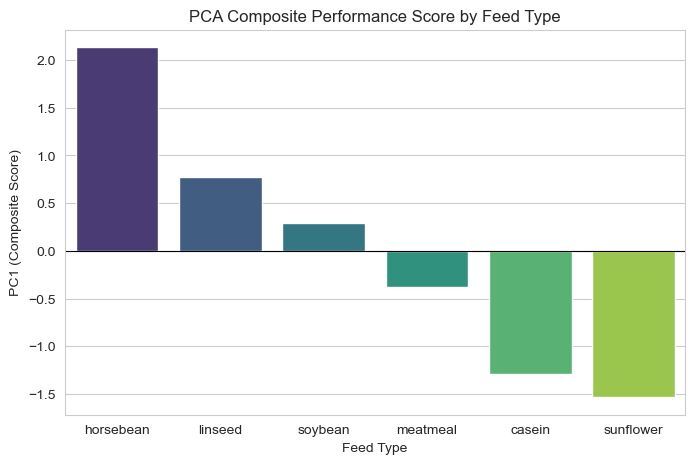

In [33]:
#PCA Score by Feed 

feed_sorted = feed_profile.sort_values('PC1', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='feed', y='PC1', data=feed_sorted, palette='viridis')
plt.title('PCA Composite Performance Score by Feed Type')
plt.xlabel('Feed Type')
plt.ylabel('PC1 (Composite Score)')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

In [34]:
feed_profile[['feed','mean','PC1']]

,feed,mean,PC1
0,casein,0.803301,-1.285105
1,horsebean,-1.304274,2.133754
2,linseed,-0.549004,0.772837
3,meatmeal,0.201223,-0.377545
4,soybean,-0.191962,0.289708
5,sunflower,0.872099,-1.533648


In [36]:
##Computing  Cosine Similarity Between Feed Types

# To recommend similar feeds, I need a similarity score between every pair of feed types. I'm computing cosine similarity on the full 4-dimensional profile (mean, std, min, max) rather than on the single PC1 score.
# Comparing single numbers with cosine similarity only tells you whether both numbers are positive or negative (the result collapses to only +1 or -1), which isn't useful for ranking. Using the richer profile gives a properly graded similarity score between every pair of feeds.
sim_matrix = cosine_similarity(profile_matrix)
sim_df = pd.DataFrame(sim_matrix, index=feed_profile['feed'], columns=feed_profile['feed'])
sim_df.round(3)


feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.000,-0.053,0.510,0.889,0.714,0.990
horsebean,-0.053,1.000,0.831,0.406,0.661,-0.144
linseed,0.510,0.831,1.000,0.844,0.966,0.430
meatmeal,0.889,0.406,0.844,1.000,0.953,0.845
soybean,0.714,0.661,0.966,0.953,1.000,0.646
sunflower,0.990,-0.144,0.430,0.845,0.646,1.000


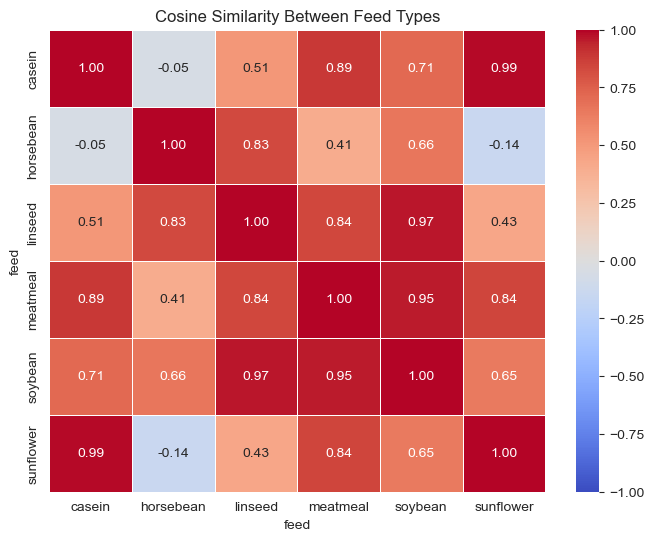

In [37]:
#Visualizing the Similarity Matrix 

plt.figure(figsize=(8, 6))
sns.heatmap(sim_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Cosine Similarity Between Feed Types')
plt.show()

In [ ]:
# The heatmap shows strong similarity clusters: 

# Linseed, soybean, and meatmeal are all highly similar to each other, and casein and sunflower are highly similar to each other, while horsebean stands apart from most other feeds , consistent with it being the clear low-performing outlier in the boxplot from Step 1.

In [ ]:
##### 4.1 Build a Recommendation Function

This function turns the similarity matrix into an actual recommendation: 
given a feed type, it returns the most similar alternatives, ranked highest to lowest.

In [38]:
def recommend_similar_feeds(target_feed, sim_df, top_n=3):
    similarities = sim_df[target_feed].drop(target_feed).sort_values(ascending=False)
    return similarities.head(top_n)

# An example:
recommend_similar_feeds('horsebean', sim_df)

feed
linseed     0.830921
soybean     0.661111
meatmeal    0.405563
Name: horsebean, dtype: float64